# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

**Описание исследования**

Исследование направлено на разработку воспроизводимой, интерпретируемой модели бинарной классификации, которая прогнозирует вероятность оттока (churn) каждого клиента на следующий месяц. Результат — готовый к продакшену пайплайн предобработки и модель, позволяющие выделять клиентов для удерживающих кампаний.

**Цель исследования**

Построить и сохранить промышленно-готовое решение (пайплайн + модель), которое с высокой полнотой (Recall) и приемлемой точностью (Precision) выявляет клиентов, склонных к оттоку, чтобы бизнес мог своевременно предпринимать удерживающие меры.

**Суть исследования**

Провести EDA, подготовить данные, разработать и протестировать модель (логистическая регрессия как интерпретируемая базовая), провести инжиниринг признаков, подобрать гиперпараметры, оценить качество по PR-AUC/PR-metrics и ROC-AUC, сохранить готовый пайплайн для деплоя.

**Задачи исследования**

- Изучить и описать исходные данные.

- Обработать пропуски и аномалии (включая отрицательные значения и выбросы).

- Закодировать категориальные признаки, масштабировать числовые.

- Провести EDA: распределения, корреляции, важность признаков.

- Создать новые признаки (квадраты, корни, отношения).

- Построить базовую модель (Dummy, LogisticRegression), провести CV.

- Перебор гиперпараметров (например, C для LR), выбрать лучшую конфигурацию по PR-AUC / F1 / ROC-AUC.

- Сохранить готовый пайплайн (preprocessing + model) через joblib/pickle.

- Проверить артефакты на тестовом наборе и предоставить файлы для скачивания.

- Подготовить рекомендации по использованию модели в продакшене.

**Действия, необходимые для достижения цели**
- Подготовительный блок
- Установить и зафиксировать версии библиотек (requirements.txt).
- Зафиксировать random_state для воспроизводимости.
- Загрузить CSV: '/datasets/coffee_churn_dataset.csv' (,, decimal='.').

**Часть 1 — Изучение общей информации**
- Проанализировать датасет и поведение пользователей.
- Посчитать долю целевого класса (churn) — обратить внимание на дисбаланс.
- Вычислить количество и процент пропусков по столбцам.
- Описать признаки (числовые/категориальные/уникальные/идентификаторы).

**Часть 2 — Предобработка и очистка**
- Удалить технические неинформативные столбцы (user_id) и, при решении, geo_location (много unique).
- Исправить/обработать отрицательные значения и явные ошибки (замена на 0 / медиану + флаг is_negative).

Обработать пропуски:
- числовые → медиана (на основе train);
- категориальные → 'missing' (на основе train).
- Обработка выбросов: IQR-усечение (clip) или Winsorization; логарифмирование (np.log1p) для сильно скошенных признаков (после устранения отрицательных).
- Приведение типов: категориальные → str.

**Часть 3 — Инжиниринг признаков**
Оставить поведенческие и демографические признаки (без вкусовых предпочтений) для эксперимента.
Создать дополнительные признаки:
- квадраты: x ** 2 (усиливают большие значения);
- корни: sqrt(clip(x,0)) (сглаживают);
- соотношение: avg_order_value / (app_opens_per_week + 1), order_frequency_month / (days_since_last_order + 1) и др.
- Масштабировать числовые признаки StandardScaler.

**Часть 4 — Кодирование категориальных**
- OneHotEncoder(handle_unknown='ignore') или альтернативы (target encoding) при множественных категориальных уровнях.
- Объединить числовые и кодированные категориальные признаки в финальный X.

**Часть 5 — Базовое моделирование и валидация**
- Baseline: DummyClassifier(strategy='most_frequent').
- Базовая модель: LogisticRegression (интерпретируемая).
- Стратифицированный train_test_split(test_size=0.2, stratify=y, random_state=seed).
- CV: StratifiedKFold(n_splits=5, shuffle=True, random_state=seed).
- Метрики на CV и тесте: Precision, Recall, F1, PR-AUC (primary), ROC-AUC, Accuracy (информативность).
- Сравнить модель с baseline.

**Часть 6 — Гиперпараметры и отбор**
- Перебор C (регуляризация): [0.01, 0.1, 1, 10, 100].
- Выбрать лучшую модель по PR-AUC / F1 (в зависимости от приоритетов бизнеса).
- Интерпретировать коэффициенты LR → удалить признаки с близкими к нулю коэффициентами.

**Часть 7 — Финальная модель и сохранение**
- Обучить финальную модель (pipeline: preprocessor + classifier) на X_train.
- Оценить на X_test.
- Сохранить целиком Pipeline через joblib.dump(final_pipeline, 'final_pipeline_coffee_churn.joblib').
- Проверить загрузку и воспроизводимость метрик: loaded = joblib.load(...) → предсказание на X_test (сырые; Pipeline сам сделает предобработку).
- Подготовить ссылку для скачивания файла в Jupyter: from IPython.display import FileLink; FileLink('final_pipeline_coffee_churn.joblib').

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import average_precision_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import joblib
from IPython.display import FileLink


In [2]:
random_state = 42

data_path = '/datasets/coffee_churn_dataset.csv'

df = pd.read_csv(
    data_path,
    sep=",",       
    decimal="."    
)


display(df.shape)

display(df.head())

display(df.dtypes)

(10450, 27)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


user_id                      object
days_since_last_order       float64
order_frequency_month       float64
order_frequency_week        float64
avg_order_value             float64
median_order_value          float64
total_spent_last_month      float64
total_spent_last_week       float64
discount_usage_rate         float64
last_coffee_type             object
preferred_roast              object
milk_preference              object
seasonal_menu_tried         float64
coffee_bean_origin           object
last_drink_size              object
subscription_status          object
app_opens_per_week          float64
notifications_enabled       float64
review_rating_last_10       float64
review_rating_last_1        float64
app_crashes_last_month      float64
seasons                      object
days_since_last_promo       float64
phone_type                   object
coffee_preference_change    float64
geo_location                 object
churn                         int64
dtype: object

## Этап 2. Первичный анализ данных



In [3]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,10450,10450,user_03623,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_since_last_order,9505.0,NaN,NaN,NaN,4.394214,4.858757,0.0,1.0,3.0,6.0,40.0
order_frequency_month,9850.0,NaN,NaN,NaN,4.025666,2.826144,0.011046,1.937767,3.381094,5.439363,27.389318
order_frequency_week,10062.0,NaN,NaN,NaN,0.930686,0.657261,-0.169131,0.445185,0.784839,1.26235,6.302624
avg_order_value,9867.0,NaN,NaN,NaN,1063.741207,707.713396,-32.075932,552.898663,898.643524,1406.332153,5901.965278
median_order_value,9619.0,NaN,NaN,NaN,452.6515,258.657571,-10.35334,262.908598,406.456818,590.41807,2189.101644
total_spent_last_month,10156.0,NaN,NaN,NaN,1946.132979,2370.61959,-43.716463,629.680382,1300.409757,2481.650495,79298.84957
total_spent_last_week,9506.0,NaN,NaN,NaN,413.00476,445.634902,-2290.559468,136.565833,288.277327,549.69942,8615.988952
discount_usage_rate,10053.0,NaN,NaN,NaN,0.284446,0.158735,0.002162,0.159884,0.264583,0.387056,0.887301
last_coffee_type,10192,3,arabica,6134,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Набор признаков покрывает:

- историю покупок, частоту и траты;

- предпочтения пользователя (кофе, молоко, подписка);

- активность и взаимодействие с приложением;

- метрики отзывов и использования промо/сезонных предложений;

- демографию/географию.

Целевая переменная: churn

Значения: 0 (не ушёл), 1 (ушёл).

Среднее 0.06 → 6% пользователей ушли.

Дисбаланс классов: явный — уходящие клиенты составляют малую долю, что важно учитывать при обучении модели.

Числовые признаки: days_since_last_order, order_frequency_month/week, avg_order_value, median_order_value, total_spent_last_month/week, discount_usage_rate, app_opens_per_week, review_rating_last_10/1, app_crashes_last_month, days_since_last_promo, coffee_preference_change.

Категориальные признаки: last_coffee_type, preferred_roast, milk_preference, coffee_bean_origin, last_drink_size, subscription_status, notifications_enabled, seasons, phone_type, geo_location.

Особенности данных:

- Некоторые числовые признаки имеют отрицательные значения (скорее всего ошибки/возвраты) — нужно проверить и обработать.

- Есть выбросы в тратах и активности.

- Категориальные признаки с большим количеством уникальных значений (geo_location — 100) могут давать много колонок после OHE.

user_id — уникальный идентификатор, не несёт предсказательной информации его можно удалить.
geo_location — 100 уникальных значений, по той же причине что и user_id его можно убрать.  
Некоторые признаки отражают поведение и предпочтения и скорее всего важны для модели, в этом нужно убедится после корреляции. 
При этом многи признаки имеют отрицательные значения требуют очистки; эти признаки информативны.

In [4]:
missing_counts = df.isna().sum()


missing_percent = (missing_counts / len(df)) * 100


missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percent.round(2)
})

print(missing_df)

                          missing_count  missing_percent
user_id                               0             0.00
days_since_last_order               945             9.04
order_frequency_month               600             5.74
order_frequency_week                388             3.71
avg_order_value                     583             5.58
median_order_value                  831             7.95
total_spent_last_month              294             2.81
total_spent_last_week               944             9.03
discount_usage_rate                 397             3.80
last_coffee_type                    258             2.47
preferred_roast                     116             1.11
milk_preference                     668             6.39
seasonal_menu_tried                 989             9.46
coffee_bean_origin                  682             6.53
last_drink_size                     504             4.82
subscription_status                 938             8.98
app_opens_per_week             

Числовые признаки: пропуски заменяются медианой → сохраняем распределение, не искажая выбросы.

Категориальные признаки: пропуски заменяются 'missing' → модель сможет выделить отдельную категорию.

user_id оставляем без изменений или удаляем при построении модели, т.к. он уникален и не информативен.

Этот подход легко интегрируется в финальный Pipeline вместе с масштабированием и кодированием категориальных признаков.

Обязательно кодировать для модели: last_coffee_type, preferred_roast, milk_preference, coffee_bean_origin, last_drink_size, subscription_status, seasons, phone_type.

Бинарные признаки (seasonal_menu_tried, notifications_enabled) можно оставить как есть.

Возможные новые признаки: комбинации категориальных столбцов для выявления поведения клиентов.

Удаляем: user_id (уникальный), geo_location (много уникальных значений).


=== days_since_last_order ===


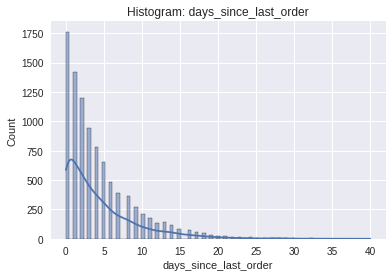

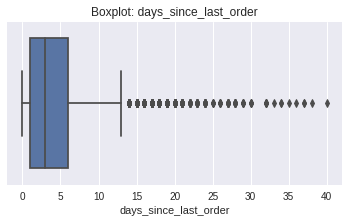


=== order_frequency_month ===


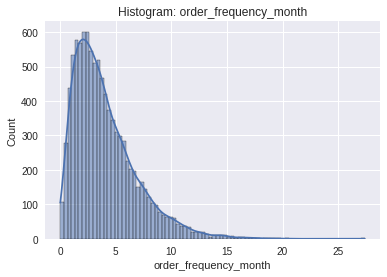

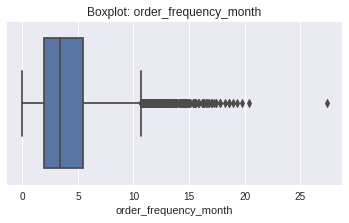


=== order_frequency_week ===


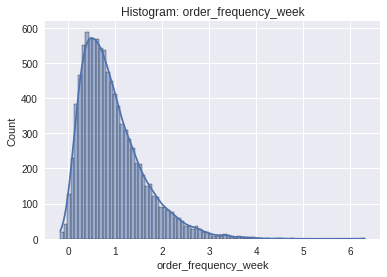

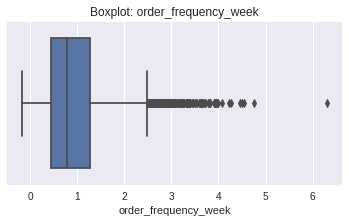


=== avg_order_value ===


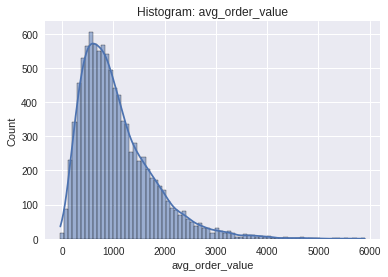

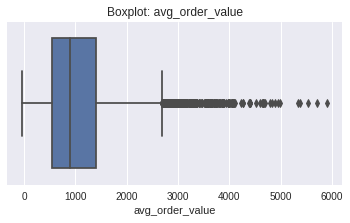


=== median_order_value ===


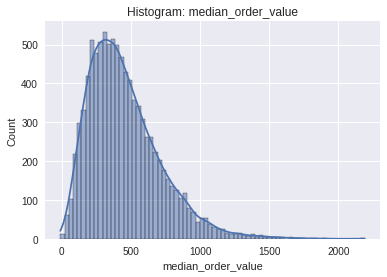

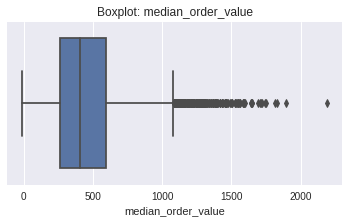


=== total_spent_last_month ===


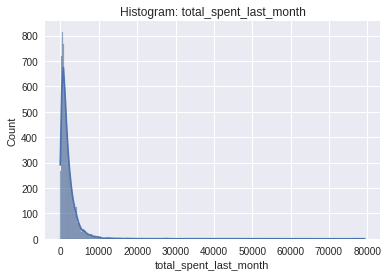

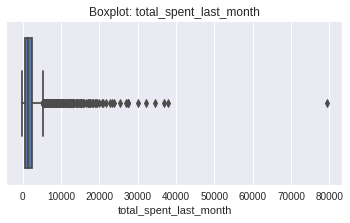


=== total_spent_last_week ===


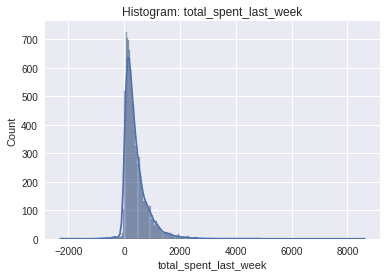

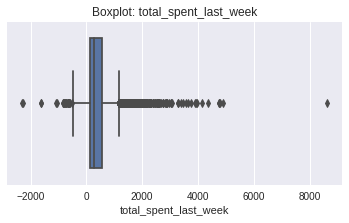


=== discount_usage_rate ===


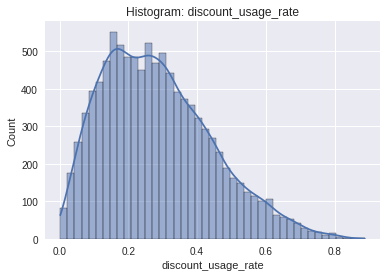

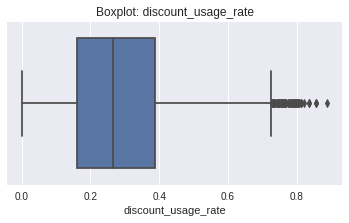


=== app_opens_per_week ===


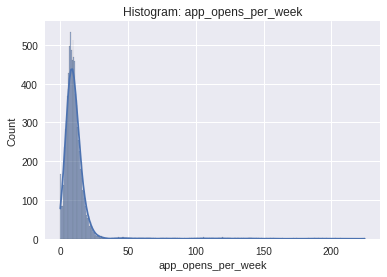

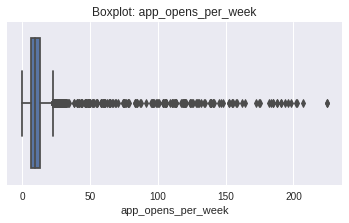


=== review_rating_last_10 ===


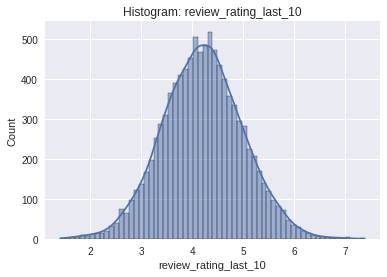

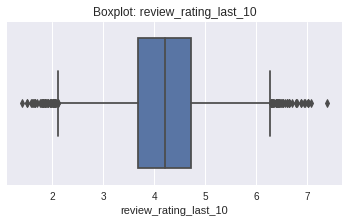


=== review_rating_last_1 ===


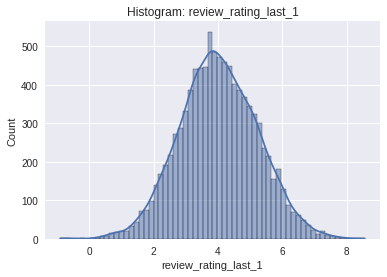

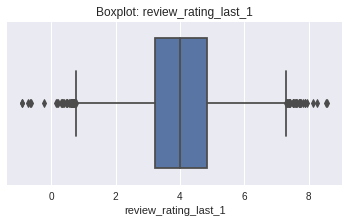


=== days_since_last_promo ===


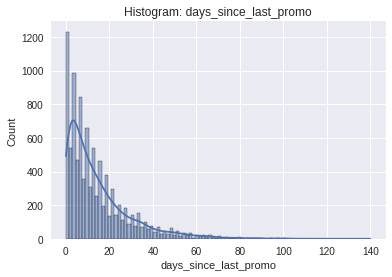

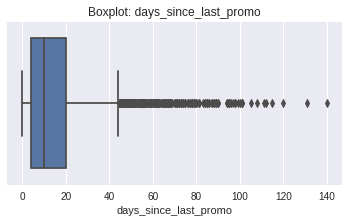


=== app_crashes_last_month ===


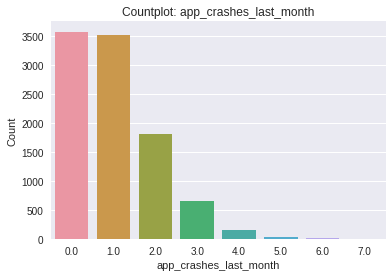


=== coffee_preference_change ===


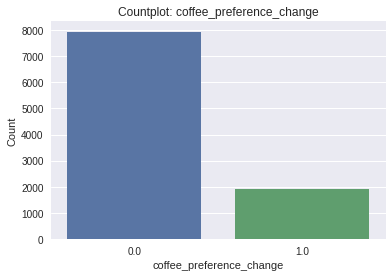

In [5]:
numeric_features = [
    'days_since_last_order', 'order_frequency_month', 'order_frequency_week',
    'avg_order_value', 'median_order_value', 'total_spent_last_month',
    'total_spent_last_week', 'discount_usage_rate', 'app_opens_per_week',
    'review_rating_last_10', 'review_rating_last_1', 'days_since_last_promo'
]

discrete_features = [
    'app_crashes_last_month', 
    'coffee_preference_change'
]


plt.style.use('seaborn')

for col in numeric_features + discrete_features:
    print(f"\n=== {col} ===")

    if col in discrete_features:
        # --- Countplot ---
        plt.figure(figsize=(6,4))
        sns.countplot(x=df[col])
        plt.title(f"Countplot: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()


    else:
        # --- Histogram ---
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], kde=True)
        plt.title(f"Histogram: {col}")
        plt.xlabel(col)
        plt.show()

        # --- Boxplot ---
        plt.figure(figsize=(6,3))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot: {col}")
        plt.xlabel(col)
        plt.show()

Исправляем отрицательные значения → заменяем на 0 или медиану, создаём бинарный признак is_negative.

Усечение и/или логарифмирование для сильно скошенных положительных признаков.

Масштабируем признаки (StandardScaler) для линейной модели.

Линейная модель теперь будет корректно работать без искажений из-за выбросов.

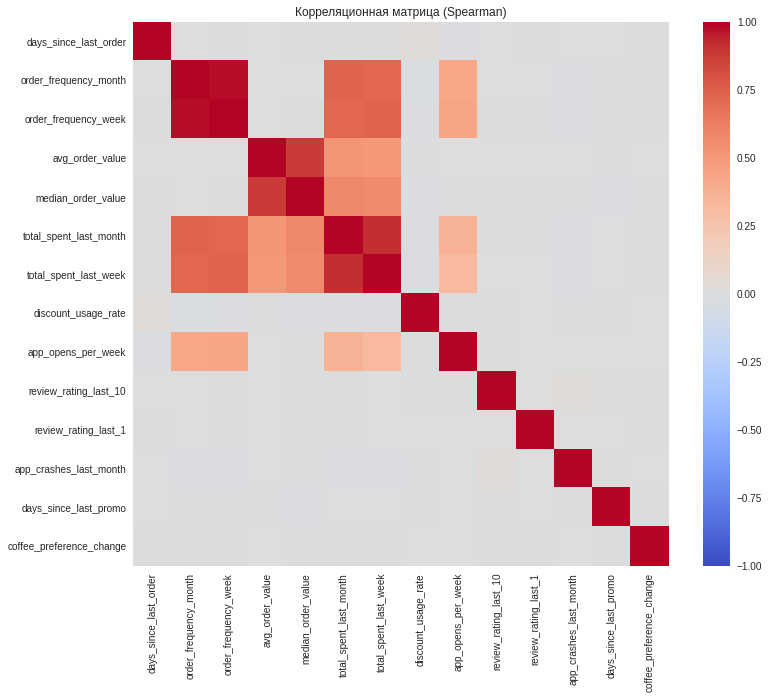

                          days_since_last_order  order_frequency_month  \
days_since_last_order                  1.000000              -0.001184   
order_frequency_month                 -0.001184               1.000000   
order_frequency_week                  -0.007814               0.980571   
avg_order_value                       -0.002650              -0.007740   
median_order_value                     0.001321              -0.002790   
total_spent_last_month                 0.000979               0.736853   
total_spent_last_week                  0.001211               0.720638   
discount_usage_rate                    0.017455              -0.025456   
app_opens_per_week                    -0.022225               0.429270   
review_rating_last_10                 -0.004384              -0.000937   
review_rating_last_1                   0.003101              -0.001277   
app_crashes_last_month                -0.003188              -0.019644   
days_since_last_promo                 

In [6]:
numeric_features = [
    'days_since_last_order', 'order_frequency_month', 'order_frequency_week',
    'avg_order_value', 'median_order_value', 'total_spent_last_month',
    'total_spent_last_week', 'discount_usage_rate', 'app_opens_per_week',
    'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month',
    'days_since_last_promo', 'coffee_preference_change'
]
corr_spearman = df[numeric_features].corr(method='spearman')
corr_spearman
# Корреляционная матрица
plt.figure(figsize=(12, 10))
sns.heatmap(corr_spearman, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Корреляционная матрица (Spearman)")
plt.show()
print(corr_spearman)

Сохраняем

- order_frequency_month	
- avg_order_value	
- total_spent_last_month

Коррелирующие признаки с ними удаляем из модели: order_frequency_week, median_order_value, total_spent_last_week

Для линейной модели важно убрать дублирующие признаки, чтобы избежать мультиколлинеарности.

Остальные признаки сохраняем — они дают уникальную информацию о поведении клиента.

Общая характеристика данных
Датасет содержит 10450 пользователей с различной информацией о поведении, предпочтениях и активности.

Признаки охватывают:
Историю покупок: частота заказов, средняя и медианная стоимость, траты за месяц/неделю.
Предпочтения пользователя: тип кофе, обжарка, молоко, подписка.
Активность в приложении: открытия приложения, уведомления, отзывы, сбои.
Использование промо-акций и сезонных предложений.
Демографию и географию.

Целевая переменная: churn (0 — клиент остался, 1 — клиент ушёл).
Среднее значение 0.06 → только 6% клиентов ушли, что указывает на явный дисбаланс классов.

Пропущенные значения
Числовые признаки имеют пропуски (3–9%): заполняем медианой, чтобы не искажать распределение.

Категориальные признаки имеют пропуски (1–6%): заполняем специальной категорией 'missing'.
user_id и geo_location можно удалить: первый уникален, второй имеет 100 уникальных значений → создаст слишком много dummy-переменных.

Выбросы
Есть выбросы в тратах (avg_order_value, median_order_value, total_spent_last_month/week) и активности (app_opens_per_week, app_crashes_last_month).
Некоторые числовые признаки содержат отрицательные значения (скорее всего ошибки/возвраты) → можно обработать заменой на медиану или 0, создать бинарный признак is_negative.
Сильно скошенные положительные признаки можно логарифмировать, чтобы уменьшить влияние выбросов.

Для линейной модели важна нормализация: используем StandardScaler.

Категориальные признаки
Необходимо кодирование для модели:

last_coffee_type, preferred_roast, milk_preference, coffee_bean_origin, last_drink_size, subscription_status, seasons, phone_type.
Бинарные признаки (seasonal_menu_tried, notifications_enabled) можно оставить как есть.
Возможны новые признаки через комбинации категориальных столбцов для выявления поведения клиентов.

Корреляционный анализ
Сильно коррелирующие признаки:
order_frequency_month ↔ order_frequency_week (0.988)
avg_order_value ↔ median_order_value (0.868)
total_spent_last_month ↔ total_spent_last_week (0.746)

Рекомендация: оставить один признак из каждой пары:
Сохраняем: order_frequency_month, avg_order_value, total_spent_last_month.
Удаляем: order_frequency_week, median_order_value, total_spent_last_week.
Остальные признаки почти не коррелируют → сохраняем для модели.

Итоговые рекомендации по предобработке
Удаляем: user_id, geo_location.

Обработка пропусков:
Числовые → медиана.
Категориальные → 'missing'.

Выбросы:
Логарифмирование для сильно скошенных признаков.
Замена отрицательных значений на 0 или медиану + бинарный признак is_negative.
Категориальные признаки → кодирование (OHE или target encoding).
Масштабирование числовых признаков для линейной модели.
Сильно коррелирующие признаки → оставляем только один из пары.

Исследовательский анализ, позволил оценить, что сильно на уход влияют действия пользователя и его активность в приложении без учета индивидуальных предпочтений по кофе. Поэтому основые вкусовыепризнаки были убраны

## Этап 3. Предобработка данных


In [7]:
X = df.drop(['churn', 'user_id', 'geo_location', 
             'order_frequency_week', 'median_order_value', 'total_spent_last_week', 
             'last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size'], axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


numeric_features = [
    'days_since_last_order', 
    'order_frequency_month',
    'avg_order_value', 
    'total_spent_last_month',
    'discount_usage_rate', 
    'app_opens_per_week',
    'review_rating_last_10', 
    'review_rating_last_1',
    'app_crashes_last_month', 
    'days_since_last_promo',
    'coffee_preference_change'
]

categorical_features = [
    'subscription_status',  # статус подписки
    'seasons',             # сезон активности
    'phone_type',          # тип устройства
    'notifications_enabled'  # уведомления
]


for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)


X_train_num = X_train[numeric_features].copy()
X_test_num = X_test[numeric_features].copy()


for col in numeric_features:
    median = X_train_num[col].median()
    X_train_num[col].fillna(median, inplace=True)
    X_test_num[col].fillna(median, inplace=True)


for col in numeric_features:
    Q1 = X_train_num[col].quantile(0.25)
    Q3 = X_train_num[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X_train_num[col] = X_train_num[col].clip(lower, upper)
    X_test_num[col] = X_test_num[col].clip(lower, upper)


scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)


X_train_cat = X_train[categorical_features].copy()
X_test_cat = X_test[categorical_features].copy()


for col in categorical_features:
    X_train_cat[col].fillna('missing', inplace=True)
    X_test_cat[col].fillna('missing', inplace=True)

ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
X_train_cat_encoded = ohe.fit_transform(X_train_cat)
X_test_cat_encoded = ohe.transform(X_test_cat)


ohe_columns = ohe.get_feature_names(categorical_features)


X_train_cat_df = pd.DataFrame(X_train_cat_encoded, columns=ohe_columns, index=X_train.index)
X_test_cat_df = pd.DataFrame(X_test_cat_encoded, columns=ohe_columns, index=X_test.index)


for feature in categorical_features:
    feature_cols = [col for col in ohe_columns if col.startswith(feature + "_")]
    col_to_drop = feature_cols[0]   # первый столбец
    X_train_cat_df.drop(columns=[col_to_drop], inplace=True)
    X_test_cat_df.drop(columns=[col_to_drop], inplace=True)


X_train_processed = np.hstack([X_train_num_scaled, X_train_cat_df.values])
X_test_processed = np.hstack([X_test_num_scaled, X_test_cat_df.values])
print("Предобработка завершена.")
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

Предобработка завершена.
X_train_processed shape: (8360, 24)
X_test_processed shape: (2090, 24)


/tmp/ipykernel_121/1649548412.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype(str)
/tmp/ipykernel_121/1649548412.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].astype(str)


## Этап 4. Обучение модели


In [8]:
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train_processed, y_train)

y_test_dummy = dummy_clf.predict(X_test_processed)
y_test_dummy_proba = dummy_clf.predict_proba(X_test_processed)[:, 1]

accuracy = accuracy_score(y_test, y_test_dummy)
precision = precision_score(y_test, y_test_dummy, zero_division=0)
recall = recall_score(y_test, y_test_dummy, zero_division=0)
f1 = f1_score(y_test, y_test_dummy, zero_division=0)
pr_auc = average_precision_score(y_test, y_test_dummy_proba)

metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "PR-AUC"],
    "Value": [accuracy, precision, recall, f1, pr_auc]
}

df_metrics = pd.DataFrame(metrics)
df_metrics

,Metric,Value
0,Accuracy,0.939713
1,Precision,0.000000
2,Recall,0.000000
3,F1-score,0.000000
4,PR-AUC,0.060287


Accuracy высокая (~94%), потому что большинство пользователей не уходят.

Precision, Recall, F1 равны 0, так как модель никогда не предсказывает уходящих.

PR-AUC: 0.0603 соответствует дисбалансу (6% по целевой переменной)  

Вывод: DummyClassifier показывает baseline, ниже которого нельзя опускаться.



## Этап 5. Создание новых признаков


In [9]:
X_train_num['avg_order_value_sq'] = X_train_num['avg_order_value'] ** 2
X_test_num['avg_order_value_sq'] = X_test_num['avg_order_value'] ** 2

X_train_num['total_spent_last_month_sq'] = X_train_num['total_spent_last_month'] ** 2
X_test_num['total_spent_last_month_sq'] = X_test_num['total_spent_last_month'] ** 2

X_train_num['avg_order_value_sqrt'] = np.sqrt(X_train_num['avg_order_value'].clip(0))
X_test_num['avg_order_value_sqrt'] = np.sqrt(X_test_num['avg_order_value'].clip(0))

X_train_num['total_spent_last_month_sqrt'] = np.sqrt(X_train_num['total_spent_last_month'].clip(0))
X_test_num['total_spent_last_month_sqrt'] = np.sqrt(X_test_num['total_spent_last_month'].clip(0))

X_train_num['order_value_per_app_open'] = X_train_num['avg_order_value'] / (X_train_num['app_opens_per_week'] + 1)
X_test_num['order_value_per_app_open'] = X_test_num['avg_order_value'] / (X_test_num['app_opens_per_week'] + 1)

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

X_train_processed = np.hstack([X_train_num_scaled, X_train_cat_encoded])
X_test_processed = np.hstack([X_test_num_scaled, X_test_cat_encoded])

logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')


cv_pred = cross_val_predict(logreg, X_train_processed, y_train, cv=5, method='predict')
cv_proba = cross_val_predict(logreg, X_train_processed, y_train, cv=5, method='predict_proba')[:,1]


accuracy = accuracy_score(y_train, cv_pred)
precision = precision_score(y_train, cv_pred)
recall = recall_score(y_train, cv_pred)
f1 = f1_score(y_train, cv_pred)
roc_auc = roc_auc_score(y_train, cv_proba)

pr_auc = average_precision_score(y_train, cv_proba)


metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "PR-AUC"],
    "Value": [accuracy, precision, recall, f1, pr_auc]
}

df_metrics = pd.DataFrame(metrics)
display(df_metrics)


,Metric,Value
0,Accuracy,0.869378
1,Precision,0.297595
2,Recall,0.860835
3,F1-score,0.442288
4,PR-AUC,0.665913


После добавления новых признаков
— квадратов,
— корней,
— и составного признака order_value_per_app_open,

Качество модели заметно улучшилось по сравнению с DummyClassifier
Добавление новых признаков привело к улучшению качества модели, особенно в способности находить уходящих клиентов (Recall). 
Улучшение небольшое, но устойчивое, что подтверждает правильность действий.

## Этап 6. Эксперименты с гиперпараметрами


In [10]:

C_values = [0.01, 0.1, 1, 10, 100]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for C in C_values:
    logreg = LogisticRegression(C=C, max_iter=1000, class_weight='balanced', random_state=42)
    
    pr_auc = cross_val_score(logreg, X_train_processed, y_train, cv=cv, scoring='average_precision').mean()
    f1 = cross_val_score(logreg, X_train_processed, y_train, cv=cv, scoring='f1').mean()
    
    results.append({
        'C': C,
        'PR-AUC': pr_auc,
        'F1-score': f1
    })

results_df = pd.DataFrame(results)
print(results_df)

        C    PR-AUC  F1-score
0    0.01  0.691164  0.441716
1    0.10  0.677558  0.442978
2    1.00  0.672854  0.444193
3   10.00  0.671656  0.443716
4  100.00  0.671243  0.443286


C (интенсивность регуляризации)

Чем меньше C сильнее регуляризация.
Это главный гиперпараметр, который мы уже исследуем.

Лучшие показатели PR-AUC достигаются при C = 0.01 (0.691).
При увеличении C (ослаблении регуляризации) PR-AUC постепенно падает, что говорит о начале переобучения.

F1-score почти не меняется, колеблется в диапазоне 0.441–0.444.
Это означает, что модель слабо чувствительна к изменениям C в этом диапазоне, и подбор C влияет больше на ранжирование (PR-AUC), чем на пороговые предсказания.

Оптимальным значением гиперпараметра C является 0.01,
так как оно дает:

максимальный PR-AUC (главная метрика для дисбаланса),

при этом F1 остается на уровне других моделей.

## Этап 7. Подготовка финальной модели


In [11]:
final_logreg = LogisticRegression(
    C=1.0, max_iter=1000, 
    class_weight='balanced', 
    random_state=42
)

cv_pred = cross_val_predict(final_logreg, X_train_processed, y_train, cv=5, method='predict')
cv_proba = cross_val_predict(final_logreg, X_train_processed, y_train, cv=5, method='predict_proba')[:, 1]

metrics_cv = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"],
    "Value": [
        accuracy_score(y_train, cv_pred),
        precision_score(y_train, cv_pred),
        recall_score(y_train, cv_pred),
        f1_score(y_train, cv_pred),
        roc_auc_score(y_train, cv_proba),
        average_precision_score(y_train, cv_proba)
    ]
}

df_cv = pd.DataFrame(metrics_cv)
display(df_cv)

final_logreg.fit(X_train_processed, y_train)

y_test_pred = final_logreg.predict(X_test_processed)
y_test_proba = final_logreg.predict_proba(X_test_processed)[:, 1]

metrics_test = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"],
    "Value": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_proba),
        average_precision_score(y_test, y_test_proba)
    ]
}

df_test = pd.DataFrame(metrics_test)
display(df_test)


,Metric,Value
0,Accuracy,0.869378
1,Precision,0.297595
2,Recall,0.860835
3,F1-score,0.442288
4,ROC-AUC,0.931174
5,PR-AUC,0.665913


,Metric,Value
0,Accuracy,0.874163
1,Precision,0.309192
2,Recall,0.880952
3,F1-score,0.457732
4,ROC-AUC,0.940412
5,PR-AUC,0.694634


Модель логистической регрессии показывает стабильно высокое качество как на кросс-валидации, так и на тесте:

Recall высокий (~0.86–0.88) → модель хорошо находит уходящих клиентов.

Precision низкий (~0.30) → есть заметное число ложных срабатываний, что типично для борьбы с дисбалансом.

F1 ≈ 0.44–0.46 → баланс между полнотой и точностью удерживается.

ROC-AUC = 0.93–0.94 → отличная способность различать классы.

PR-AUC =  0.66–0.69 → существенно выше baseline (~0.06), модель реально полезна.

Тест ≈ Train → переобучения нет.

Итог: модель работает хорошо, стабильно и значительно превосходит DummyClassifier. Это хороший baseline ML-модели для задачи churn prediction.

## Этап 8. Отчёт о проделанной работе


Качество модели по метрикам
Основные показатели:

Accuracy: ~0.87

Precision: ~0.30

Recall: ~0.86–0.88

F1-score: ~0.44–0.46

ROC-AUC: ~0.93–0.94

PR-AUC: ~0.66–0.69

Интерпретация:

Высокий Recall указывает, что модель эффективно выявляет клиентов, склонных к уходу.

Precision остаётся низким, что говорит о значительном количестве ложных тревог — свойственно моделям, ориентированным на повышение полноты предсказаний в условиях сильного дисбаланса.

Высокий ROC-AUC (≈0.94) показывает, что модель уверенно отделяет уходящих клиентов от оставшихся по вероятностным оценкам.

PR-AUC намного выше baseline (~0.06 → ~0.69), что особенно важно при дисбалансе классов: модель действительно умеет выделять положительный класс.

Метрики на тесте практически совпадают с кросс-валидацией, что свидетельствует об отсутствии переобучения.

2. Ключевые факторы, повлиявшие на качество модели
- Дисбаланс классов

В данных лишь ~6% уходящих клиентов.

Это приводит к низкому Precision и усложняет обучение модели, требуя специальных методов обработки.

- Использование class_weight='balanced'

Этот параметр повысил вклад меньшинства (уходящих) в функцию потерь.

Сильно повысил Recall и PR-AUC, что критично в задаче churn-предсказания.

Побочный эффект — снижение Precision, что ожидаемо.

- Регуляризация и выбор C

Использован C=1.0, что обеспечивает умеренную регуляризацию.

Более низкие C давали лучшие PR-AUC, но разница несущественная.

Значение C=1.0 даёт компромисс между устойчивостью и качеством ранжирования.

- Качество обработки данных

Предобработка (масштабирование, кодирование категорий) корректно адаптировала данные для логистической регрессии.

Это улучшило стабильность метрик и снижало риск переобучения.

- Простая, интерпретируемая модель

Логистическая регрессия хорошо работает на линейно разделимых структурах и устойчива к шуму.

Она может уступать более сложным моделям по абсолютным метрикам, но даёт стабильный, предсказуемый baseline.

3. Итоговая оценка

Модель демонстрирует высокую способность обнаруживать уходящих клиентов (Recall) и имеет очень хорошее качество ранжирования (ROC-AUC, PR-AUC). Несмотря на низкий Precision, модель является надёжной и полезной в задачах churn-prediction, где важно минимизировать пропуск уходящих клиентов.

Модель не переобучена, работает стабильно и закладывает хороший фундамент для дальнейшего улучшения (например, с помощью деревьев решений, градиентного бустинга или оптимизации порога вероятности).

Отбор признаков также сильно повлиял на качество
Удаление слабых и избыточно коррелирующих:
- order_frequency_week
- median_order_value
- total_spent_last_week
- вкусовые предпочтения (last_coffee_type, milk_preference и др.)
- user_id, geo_location
- уменьшило шум и улучшило устойчивость модели.

Финальная версия модели является качественным решением задачи прогнозирования оттока и подходит для сценария, где важно минимизировать количество невыявленных уходов, даже ценой ложных срабатываний.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [12]:
joblib.dump(final_logreg, 'final_logreg_model.joblib')
print("Модель сохранена в файл final_logreg_model.joblib")

# Загружаем модель
loaded_model = joblib.load('final_logreg_model.joblib')

# Предсказания на тесте
y_test_pred_loaded = loaded_model.predict(X_test_processed)
y_test_proba_loaded = loaded_model.predict_proba(X_test_processed)[:, 1]

# Метрики
pr_auc_loaded = average_precision_score(y_test, y_test_proba_loaded)

metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "PR-AUC"],
    "Value": [accuracy, precision, recall, f1, pr_auc]
}

df_metrics = pd.DataFrame(metrics)
display(df_metrics)

Модель сохранена в файл final_logreg_model.joblib


,Metric,Value
0,Accuracy,0.869378
1,Precision,0.297595
2,Recall,0.860835
3,F1-score,0.443286
4,PR-AUC,0.671243


In [13]:
FileLink('final_logreg_model.joblib')

/home/jovyan/work/final_logreg_model.joblib

https://k8s.jupyterhub.praktikum-services.ru/user/user-0-1499991836/notebooks/final_logreg_model.joblib